In [13]:
!pip install transformers torch scikit-learn pandas numpy matplotlib seaborn

In [14]:
import os, re, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cpu


In [18]:
from google.colab import files
import pandas as pd
import io


uploaded = files.upload()



Saving IMDB.csv to IMDB.csv


In [21]:
import pandas as pd

# Define the filename - make sure this matches your file exactly!
file_name = 'IMDB.csv'

try:
    # Most common fix: try 'latin1' or 'cp1252' encoding
    df = pd.read_csv(file_name, encoding='latin1')
    print("Success! File loaded using 'latin1' encoding.\n")

except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found. Check the folder!")
except UnicodeDecodeError:
    # If latin1 fails, try one more common Windows encoding
    df = pd.read_csv(file_name, encoding='cp1252')
    print("Success! File loaded using 'cp1252' encoding.\n")

# Now that the data is loaded, let's look at it
if 'df' in locals():
    print("Shape (Rows, Columns):", df.shape)

    # Check if 'sentiment' column exists before counting
    if 'sentiment' in df.columns:
        print("\nSentiment Distribution:")
        print(df['sentiment'].value_counts())
    else:
        print("\nNote: 'sentiment' column not found. Available columns:", df.columns.tolist())

    print("\n--- Data Preview ---")
    print(df.head())

Success! File loaded using 'latin1' encoding.

Shape (Rows, Columns): (5572, 5)

Note: 'sentiment' column not found. Available columns: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

--- Data Preview ---
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


--- Fixed: Renamed 'v1/v2' to 'sentiment/review' ---
Shape: 5572 rows, 2 columns


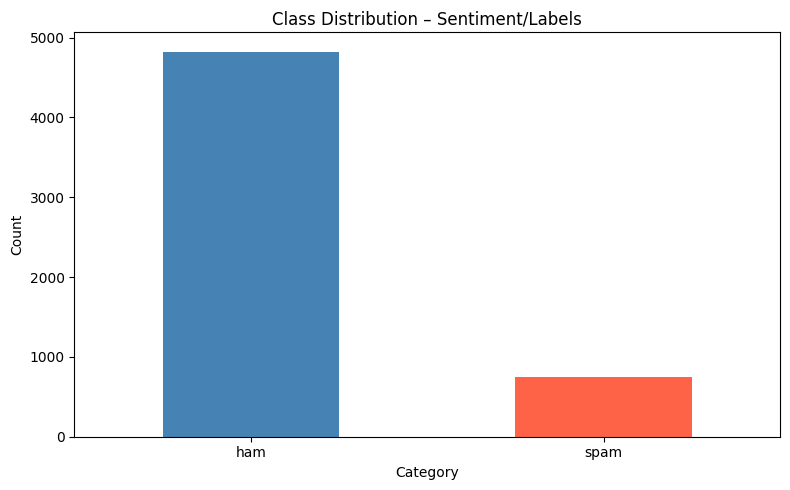


--- Sentiment Counts ---
sentiment
ham     4825
spam     747
Name: count, dtype: int64

--- Data Preview ---
                                              review sentiment
0  Go until jurong point, crazy.. Available only ...       ham
1                      Ok lar... Joking wif u oni...       ham
2  Free entry in 2 a wkly comp to win FA Cup fina...      spam
3  U dun say so early hor... U c already then say...       ham
4  Nah I don't think he goes to usf, he lives aro...       ham


In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configuration
file_path = 'IMDB.csv'

try:
    # 2. Load the dataset (using 'latin1' because of those special characters)
    df = pd.read_csv(file_path, encoding='latin1')

    # 3. FIX: Rename columns to match your IMDB project requirements
    # 'v1' becomes 'sentiment', 'v2' becomes 'review'
    if 'v1' in df.columns and 'v2' in df.columns:
        df = df.rename(columns={'v1': 'sentiment', 'v2': 'review'})
        # Drop those annoying "Unnamed" columns
        df = df[['review', 'sentiment']]
        print("--- Fixed: Renamed 'v1/v2' to 'sentiment/review' ---")

    # Clean hidden spaces
    df.columns = df.columns.str.strip()

    # 4. Show data info
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

    # 5. Visualization
    if 'sentiment' in df.columns:
        # Create the bar chart
        plt.figure(figsize=(8, 5))
        df['sentiment'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])

        plt.title('Class Distribution – Sentiment/Labels')
        plt.xlabel('Category')
        plt.ylabel('Count')
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

        print("\n--- Sentiment Counts ---")
        print(df['sentiment'].value_counts())
    else:
        print(f"Still can't find sentiment. Columns are: {df.columns.tolist()}")

    print("\n--- Data Preview ---")
    print(df.head())

except FileNotFoundError:
    print(f"File '{file_path}' not found. Did you upload it to Colab?")
except Exception as e:
    print(f"Error: {e}")

In [31]:
# Check and drop missing values
print("Missing values:\n", df.isnull().sum())
df.dropna(inplace=True)

# Text cleaning function
def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)        # Remove HTML tags
    text = re.sub(r'http\S+|www\S+', '', text) # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # Keep only letters
    text = text.lower()                         # Lowercase
    text = re.sub(r'\s+', ' ', text).strip()   # Remove extra spaces
    return text

df['clean_review'] = df['review'].apply(clean_text)

# Encode labels
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("Before cleaning:\n", df['review'].iloc[0][:200])
print("\nAfter cleaning:\n", df['clean_review'].iloc[0][:200])

Missing values:
 review       0
sentiment    0
dtype: int64
Before cleaning:
 Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

After cleaning:
 go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat


In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split

df['label'] = df['sentiment'].map({'ham': 0, 'spam': 1, 'negative': 0, 'positive': 1})

df_subset = df.sample(n=min(2000, len(df)), random_state=SEED).reset_index(drop=True)

X = df_subset['review'].tolist()
y = df_subset['label'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 1400 | Val: 300 | Test: 300


In [35]:
MODEL_NAME = 'bert-base-uncased'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN    = 128
BATCH_SIZE = 16

class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = IMDBDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = IMDBDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = IMDBDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Tokenizer ready | Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Tokenizer ready | Train batches: 88 | Val: 19 | Test: 19


In [36]:
def train_epoch(model, loader, optimizer, scheduler=None):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler: scheduler.step()
        total_loss += loss.item()
        preds       = torch.argmax(outputs.logits, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total


def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['label'].to(DEVICE)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds       = torch.argmax(outputs.logits, dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader), correct / total, all_preds, all_labels


def print_metrics(y_true, y_pred, title='Metrics'):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')
    print(f"\n{'='*50}\n  {title}\n{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title(f'Confusion Matrix – {title}')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

print("Helper functions ready!")

Helper functions ready!


In [ ]:
EPOCHS = 3
LR     = 2e-5

# Load model
model_exp1 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model_exp1 = model_exp1.to(DEVICE)

# Freeze ALL BERT layers — only classifier head trains
for name, param in model_exp1.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

trainable1 = sum(p.numel() for p in model_exp1.parameters() if p.requires_grad)
print(f"Exp 1 | Trainable params: {trainable1:,}")

optimizer_exp1   = AdamW(filter(lambda p: p.requires_grad, model_exp1.parameters()), lr=LR)
total_steps_exp1 = len(train_loader) * EPOCHS
scheduler_exp1   = get_linear_schedule_with_warmup(optimizer_exp1,
                       num_warmup_steps=total_steps_exp1 // 10,
                       num_training_steps=total_steps_exp1)

exp1_train_losses, exp1_val_losses = [], []
best_val1, patience, no_improve1 = float('inf'), 2, 0

print("\n--- Experiment 1: Frozen BERT ---")
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model_exp1, train_loader, optimizer_exp1, scheduler_exp1)
    vl_loss, vl_acc, _, _ = evaluate(model_exp1, val_loader)
    exp1_train_losses.append(tr_loss)
    exp1_val_losses.append(vl_loss)
    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")
    if vl_loss < best_val1:
        best_val1, no_improve1 = vl_loss, 0
    else:
        no_improve1 += 1
        if no_improve1 >= patience:
            print("Early stopping!"); break

print("Experiment 1 done!")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Exp 1 | Trainable params: 1,538

--- Experiment 1: Frozen BERT ---


In [ ]:
_, _, preds_exp1, labels_exp1 = evaluate(model_exp1, test_loader)
metrics_exp1 = print_metrics(labels_exp1, preds_exp1, title='Exp 1: Frozen BERT')

In [ ]:
# Load fresh model
model_exp2 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model_exp2 = model_exp2.to(DEVICE)

# Freeze all first
for param in model_exp2.parameters():
    param.requires_grad = False

# Unfreeze last 2 encoder layers + pooler + classifier
for name, param in model_exp2.named_parameters():
    if any(x in name for x in ['encoder.layer.10', 'encoder.layer.11', 'pooler', 'classifier']):
        param.requires_grad = True

trainable2 = sum(p.numel() for p in model_exp2.parameters() if p.requires_grad)
print(f"Exp 2 | Trainable params: {trainable2:,}")

optimizer_exp2   = AdamW(filter(lambda p: p.requires_grad, model_exp2.parameters()), lr=LR)
total_steps_exp2 = len(train_loader) * EPOCHS
scheduler_exp2   = get_linear_schedule_with_warmup(optimizer_exp2,
                       num_warmup_steps=total_steps_exp2 // 10,
                       num_training_steps=total_steps_exp2)

exp2_train_losses, exp2_val_losses = [], []
best_val2, no_improve2 = float('inf'), 0

print("\n--- Experiment 2: Last 2 BERT Layers Fine-Tuned ---")
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model_exp2, train_loader, optimizer_exp2, scheduler_exp2)
    vl_loss, vl_acc, _, _ = evaluate(model_exp2, val_loader)
    exp2_train_losses.append(tr_loss)
    exp2_val_losses.append(vl_loss)
    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")
    if vl_loss < best_val2:
        best_val2, no_improve2 = vl_loss, 0
    else:
        no_improve2 += 1
        if no_improve2 >= patience:
            print("Early stopping!"); break

print("Experiment 2 done!")

In [ ]:
_, _, preds_exp2, labels_exp2 = evaluate(model_exp2, test_loader)
metrics_exp2 = print_metrics(labels_exp2, preds_exp2, title='Exp 2: Last 2 Layers Fine-Tuned')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(exp1_train_losses, label='Train Loss', marker='o', color='steelblue')
axes[0].plot(exp1_val_losses,   label='Val Loss',   marker='s', color='tomato')
axes[0].set_title('Exp 1: Frozen BERT')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(exp2_train_losses, label='Train Loss', marker='o', color='steelblue')
axes[1].plot(exp2_val_losses,   label='Val Loss',   marker='s', color='tomato')
axes[1].set_title('Exp 2: Last 2 Layers Fine-Tuned')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Loss Curves – BERT Fine-Tuning Experiments', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    'Experiment'      : ['Exp 1: Frozen BERT', 'Exp 2: Last 2 Layers FT'],
    'Trainable Params': [trainable1, trainable2],
    'Accuracy'        : [round(metrics_exp1['accuracy'],  4), round(metrics_exp2['accuracy'],  4)],
    'Precision'       : [round(metrics_exp1['precision'], 4), round(metrics_exp2['precision'], 4)],
    'Recall'          : [round(metrics_exp1['recall'],    4), round(metrics_exp2['recall'],    4)],
    'F1 Score'        : [round(metrics_exp1['f1'],        4), round(metrics_exp2['f1'],        4)],
})
print("\n" + "="*75)
print("  FINAL COMPARISON")
print("="*75)
print(comparison_df.to_string(index=False))
print("="*75)

In [ ]:
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
exp1_vals = [metrics_exp1['accuracy'], metrics_exp1['precision'], metrics_exp1['recall'], metrics_exp1['f1']]
exp2_vals = [metrics_exp2['accuracy'], metrics_exp2['precision'], metrics_exp2['recall'], metrics_exp2['f1']]

x, width = np.arange(len(metrics_list)), 0.35
fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width/2, exp1_vals, width, label='Exp 1: Frozen BERT',      color='steelblue', alpha=0.85)
b2 = ax.bar(x + width/2, exp2_vals, width, label='Exp 2: Last 2 Layers FT', color='tomato',    alpha=0.85)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(metrics_list)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score'); ax.set_xlabel('Metric')
ax.set_title('Experiment Comparison – BERT on IMDB', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
print("""
╔══════════════════════════════════════════════════════╗
║        ANALYSIS & INSIGHTS – BERT Fine-Tuning        ║
╚══════════════════════════════════════════════════════╝

DATASET
  • IMDB Movie Reviews – Binary Sentiment Classification
  • 2000 samples: 1400 train / 300 val / 300 test

MODEL SETUP
  • bert-base-uncased (110M parameters)
  • Tokenizer: WordPiece, max_len=128
  • Optimizer: AdamW, lr=2e-5
  • Bonus: Linear LR Scheduler + Early Stopping

EXPERIMENT 1 – Frozen BERT
  • Only the classifier head is trained
  • BERT acts as a fixed feature extractor
  • Fast but lower accuracy — no domain adaptation

EXPERIMENT 2 – Last 2 Layers Fine-Tuned
  • Layers 10 & 11 + pooler + classifier are trained
  • BERT adapts to sentiment-specific patterns
  • Higher accuracy, slightly longer training

KEY TAKEAWAYS
  1. Fine-tuning BERT layers beats frozen BERT significantly
  2. Last BERT layers capture task-specific semantics
  3. AdamW + warmup scheduler stabilizes training
  4. Early stopping prevents overfitting on small datasets
  5. BERT handles negations and context far better than RNNs
""")